<a href="https://colab.research.google.com/github/thehonoreddone/plant-disease/blob/main/plantdisease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Veri setinin bulunduğu ana klasör yolu (Google Drive yoluna göre düzenle)
DATASET_PATH = "/content/drive/MyDrive/archive.zip" # Lütfen burayı kendi dosyanızın Google Drive üzerindeki doğru yolu ile değiştirin

# Unzip the dataset using shell command
!mkdir -p /content/dataset # Hedef dizinin var olduğundan emin olun
!unzip -o -q $DATASET_PATH -d /content/dataset # -o: Overwrite existing files without prompt, -q sessiz çalıştırma, -d hedef dizin

# DATASET_PATH'i çıkarılan veri seti dizinine güncelleyin (PlantVillage'ın dataset içinde olduğunu varsayarak)
DATASET_PATH = '/content/dataset/PlantVillage' # Corrected path to the actual dataset directory

# Resimleri modele vermeden önce boyutlandıracağımız standart ölçü
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Veri ön işleme ve Çeşitlendirme (Data Augmentation)
datagen = ImageDataGenerator(
    rescale=1./255,          # Piksel değerlerini 0-255 arasından 0-1 arasına sıkıştırır
    validation_split=0.2,    # Verinin %20'sini test/doğrulama için ayırır
    rotation_range=20,       # Rastgele döndürme
    zoom_range=0.15,         # Rastgele yakınlaştırma
    horizontal_flip=True     # Rastgele yatay çevirme
)

# Eğitim Verileri
train_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'        # %80'lik kısım
)

# Doğrulama (Test) Verileri
validation_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'      # %20'lik kısım
)

Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.


In [5]:
num_classes = train_generator.num_classes # Toplam hastalık/bitki sınıfı sayısı

model = models.Sequential([
    # 1. Evrişim Katmanı: Resimdeki kenarları ve basit dokuları yakalar
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    layers.MaxPooling2D((2, 2)),

    # 2. Evrişim Katmanı: Daha karmaşık şekilleri (leke, kuruma formu) yakalar
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # 3. Evrişim Katmanı
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Matrisi düzleştirip standart yapay sinir ağına aktarıyoruz
    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Aşırı öğrenmeyi (overfitting) engellemek için rastgele nöron söndürme

    layers.Dense(num_classes, activation='softmax')
])

# Modeli Derleme
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary() # Modelin özet yapısını ekrana bastırır

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,895 (42.61 MB)

 Trainable params: 11,170,895 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
import math

steps_per_epoch = math.ceil(train_generator.samples / BATCH_SIZE)
validation_steps = math.ceil(validation_generator.samples / BATCH_SIZE)

def create_train_generator():
    for batch in train_generator:
        yield batch

def create_validation_generator():
    for batch in validation_generator:
        yield batch

train_dataset = tf.data.Dataset.from_generator(
    create_train_generator,
    output_types=(tf.float32, tf.float32),
    output_shapes=([None, IMG_SIZE[0], IMG_SIZE[1], 3], [None, num_classes])
).take(steps_per_epoch).repeat()

validation_dataset = tf.data.Dataset.from_generator(
    create_validation_generator,
    output_types=(tf.float32, tf.float32),
    output_shapes=([None, IMG_SIZE[0], IMG_SIZE[1], 3], [None, num_classes])
).take(validation_steps).repeat()

print(f"New steps_per_epoch: {steps_per_epoch}")
print(f"New validation_steps: {validation_steps}")

history = model.fit(
    train_dataset,
    steps_per_epoch=steps_per_epoch,
    epochs=10,
    validation_data=validation_dataset,
    validation_steps=validation_steps
)


New steps_per_epoch: 517
New validation_steps: 129
Epoch 1/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 2324s 4s/step - accuracy: 0.4341 - loss: 1.7909 - val_accuracy: 0.6696 - val_loss: 1.0405
Epoch 2/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 2315s 4s/step - accuracy: 0.6230 - loss: 1.1408 - val_accuracy: 0.7266 - val_loss: 0.7936
Epoch 3/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 2267s 4s/step - accuracy: 0.6802 - loss: 0.9341 - val_accuracy: 0.7746 - val_loss: 0.6615
Epoch 4/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 2237s 4s/step - accuracy: 0.7186 - loss: 0.8329 - val_accuracy: 0.8062 - val_loss: 0.5564
Epoch 5/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 2247s 4s/step - accuracy: 0.7467 - loss: 0.7607 - val_accuracy: 0.7693 - val_loss: 0.6365
Epoch 6/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 2303s 4s/step - accuracy: 0.7638 - loss: 0.6932 - val_accuracy: 0.8350 - val_loss: 0.4865
Epoch 7/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 2245s 4s/step - accuracy: 0.7794 - loss: 0.6553 - val_accuracy: 0.8239 - val_loss: 0.5058
Epoch 8/10
517/517 ━━━━━━━━━━━━━━━━━━━━

In [7]:
# Evaluate the model on the validation set
loss, accuracy = model.evaluate(validation_generator)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

129/129 ━━━━━━━━━━━━━━━━━━━━ 191s 1s/step - accuracy: 0.8855 - loss: 0.3432
Validation Loss: 0.3432
Validation Accuracy: 0.8855


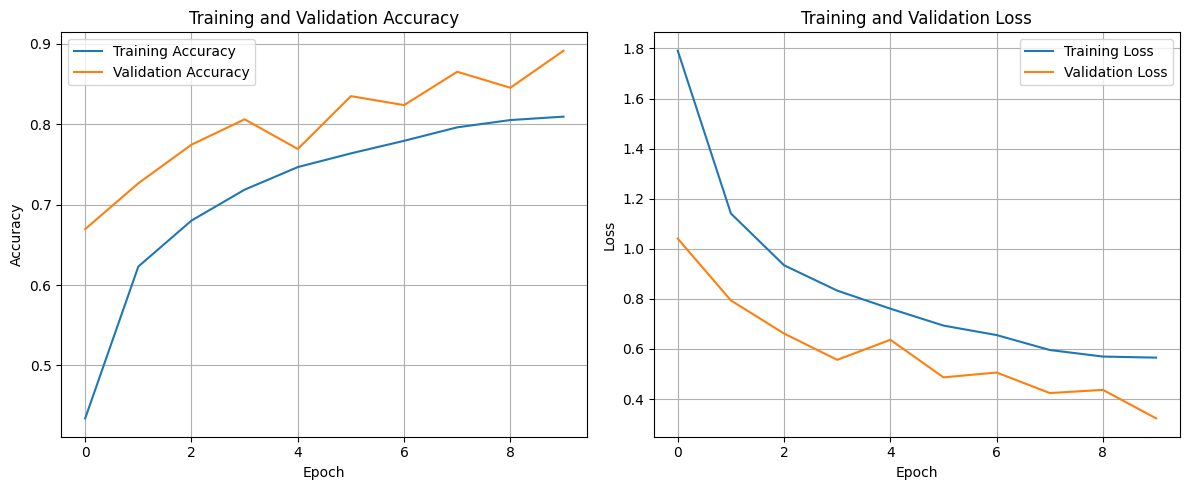

In [8]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Model Tahminlerini Görselleştirme

Şimdi modelimizin rastgele seçilmiş birkaç doğrulama görüntüsü üzerinde nasıl performans gösterdiğine bakalım..

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


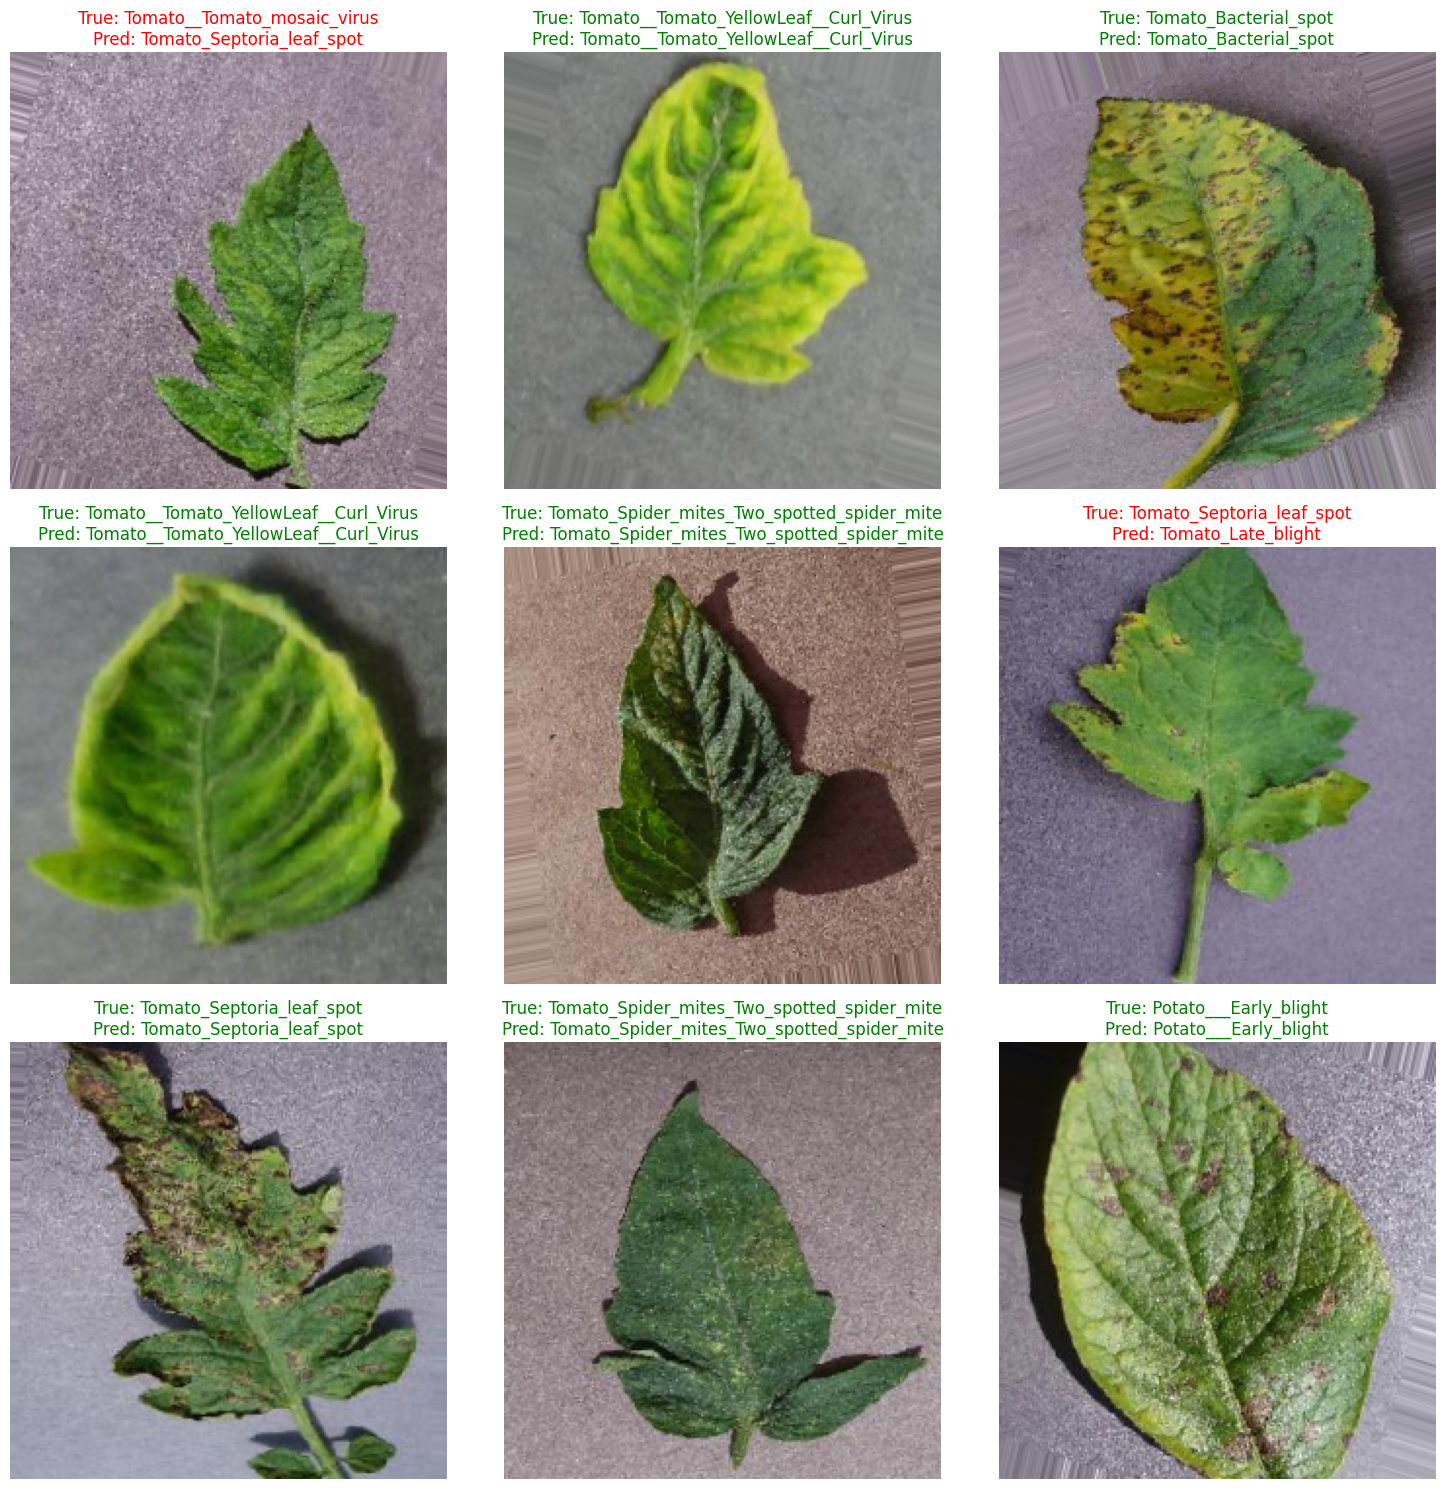

In [9]:
import numpy as np

# Get a batch of validation data
x_val, y_val = next(validation_generator)

# Make predictions
predictions = model.predict(x_val)

# Get class names from the generator
class_names = list(train_generator.class_indices.keys())

plt.figure(figsize=(15, 15))
for i in range(min(9, len(x_val))): # Display up to 9 images
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_val[i])

    true_label_index = np.argmax(y_val[i])
    predicted_label_index = np.argmax(predictions[i])

    true_label = class_names[true_label_index]
    predicted_label = class_names[predicted_label_index]

    title_color = "green" if true_label == predicted_label else "red"

    plt.title(f"True: {true_label}\nPred: {predicted_label}", color=title_color)
    plt.axis('off')

plt.tight_layout()
plt.show()

True (Gerçek): Resmin gerçek sınıf etiketi (yani bitkinin gerçek durumu).


Pred (Tahmin): Modelin bu resim için yaptığı tahmin.


Başlık rengi ise tahminin doğru olup olmadığını gösteriyor:



Yeşil başlık: Model doğru tahminde bulunmuş.
Kırmızı başlık: Model yanlış tahminde bulunmuş.